In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [102]:
def fetch_creditcard(X_y_split: bool = False
                     ) -> pd.DataFrame | tuple[pd.DataFrame, pd.Series]:
    response = requests.get("http://pipeline:8000/dataset/creditcard-churn", params={"X_y_split": X_y_split})
    payload = response.json()
    
    if X_y_split:
        X = pd.DataFrame(payload["x"], index=payload["index"])
        y = pd.Series(payload["y"], index=payload["index"])
        return X, y
    
    df = pd.DataFrame(payload["data"], index=payload["index"])
    
    return df

In [103]:
# 데이터 로드
bank_df = fetch_creditcard()
print(bank_df.head())

   creditcard_churn_id  churn  age  gender  dependents  education_id  \
0                    1      1   35       0           4             7   
1                    2      1   47       1           0             1   
2                    3      1   26       1           1             4   
3                    4      1   36       0           1             5   
4                    5      1   64       1           2             7   

   marital_id  income_id  card_type_id  relationship_months  ...  \
0           2          1             2                   23  ...   
1           4          2             4                   21  ...   
2           4          3             3                   45  ...   
3           3          5             1                   46  ...   
4           3          6             1                   12  ...   

   inactive_months  contact_count  credit_limit  revolving_balance  \
0                5              3       8882.21             385.10   
1                0

In [104]:
features = [k for k in bank_df.columns if k != "income_id"]
# features = ["revolving_balance", "transaction_count", "count_change"]
# features = ["credit_limit", "available_credit", "utilization_ratio"]
features_df = bank_df[features]
income_df = bank_df['income_id']

print(features_df.describe())
print(income_df.value_counts())

       creditcard_churn_id         churn           age        gender  \
count         10227.000000  10227.000000  10227.000000  10227.000000   
mean           5140.735993      0.162902     46.294710      0.471008   
std            2952.878921      0.369294      8.062244      0.499183   
min               1.000000      0.000000     25.000000      0.000000   
25%            2584.500000      0.000000     41.000000      0.000000   
50%            5141.000000      0.000000     46.000000      0.000000   
75%            7697.500000      0.000000     52.000000      1.000000   
max           10254.000000      1.000000     73.000000      1.000000   

         dependents  education_id    marital_id  card_type_id  \
count  10227.000000  10227.000000  10227.000000  10227.000000   
mean       2.342916      3.654737      1.837880      1.103647   
std        1.300694      1.918032      0.859548      0.409181   
min        0.000000      1.000000      1.000000      1.000000   
25%        1.000000      2

In [105]:
features_known_df = features_df[income_df != 6]
features_unknown_df = features_df[income_df == 6]
income_known_df = income_df[income_df != 6]
income_unknown_df = income_df[income_df == 6]

print(features_known_df.describe())
print(income_known_df.value_counts())

       creditcard_churn_id        churn          age       gender  \
count          9104.000000  9104.000000  9104.000000  9104.000000   
mean           5112.477592     0.162017    46.301076     0.522847   
std            2977.227934     0.368486     7.980682     0.499505   
min               1.000000     0.000000    25.000000     0.000000   
25%            2537.750000     0.000000    41.000000     0.000000   
50%            5070.500000     0.000000    46.000000     1.000000   
75%            7700.250000     0.000000    52.000000     1.000000   
max           10254.000000     1.000000    73.000000     1.000000   

        dependents  education_id   marital_id  card_type_id  \
count  9104.000000   9104.000000  9104.000000   9104.000000   
mean      2.350945      3.664982     1.838203      1.104130   
std       1.296940      1.917392     0.858344      0.406647   
min       0.000000      1.000000     1.000000      1.000000   
25%       1.000000      2.000000     1.000000      1.000000   


In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_known_df_scaled = scaler.fit_transform(features_known_df)
features_unknown_df_scaled = scaler.transform(features_unknown_df)

In [107]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
features_known_df_lda = lda.fit_transform(features_known_df_scaled, income_known_df)
features_unknown_df_lda = lda.transform(features_unknown_df_scaled)

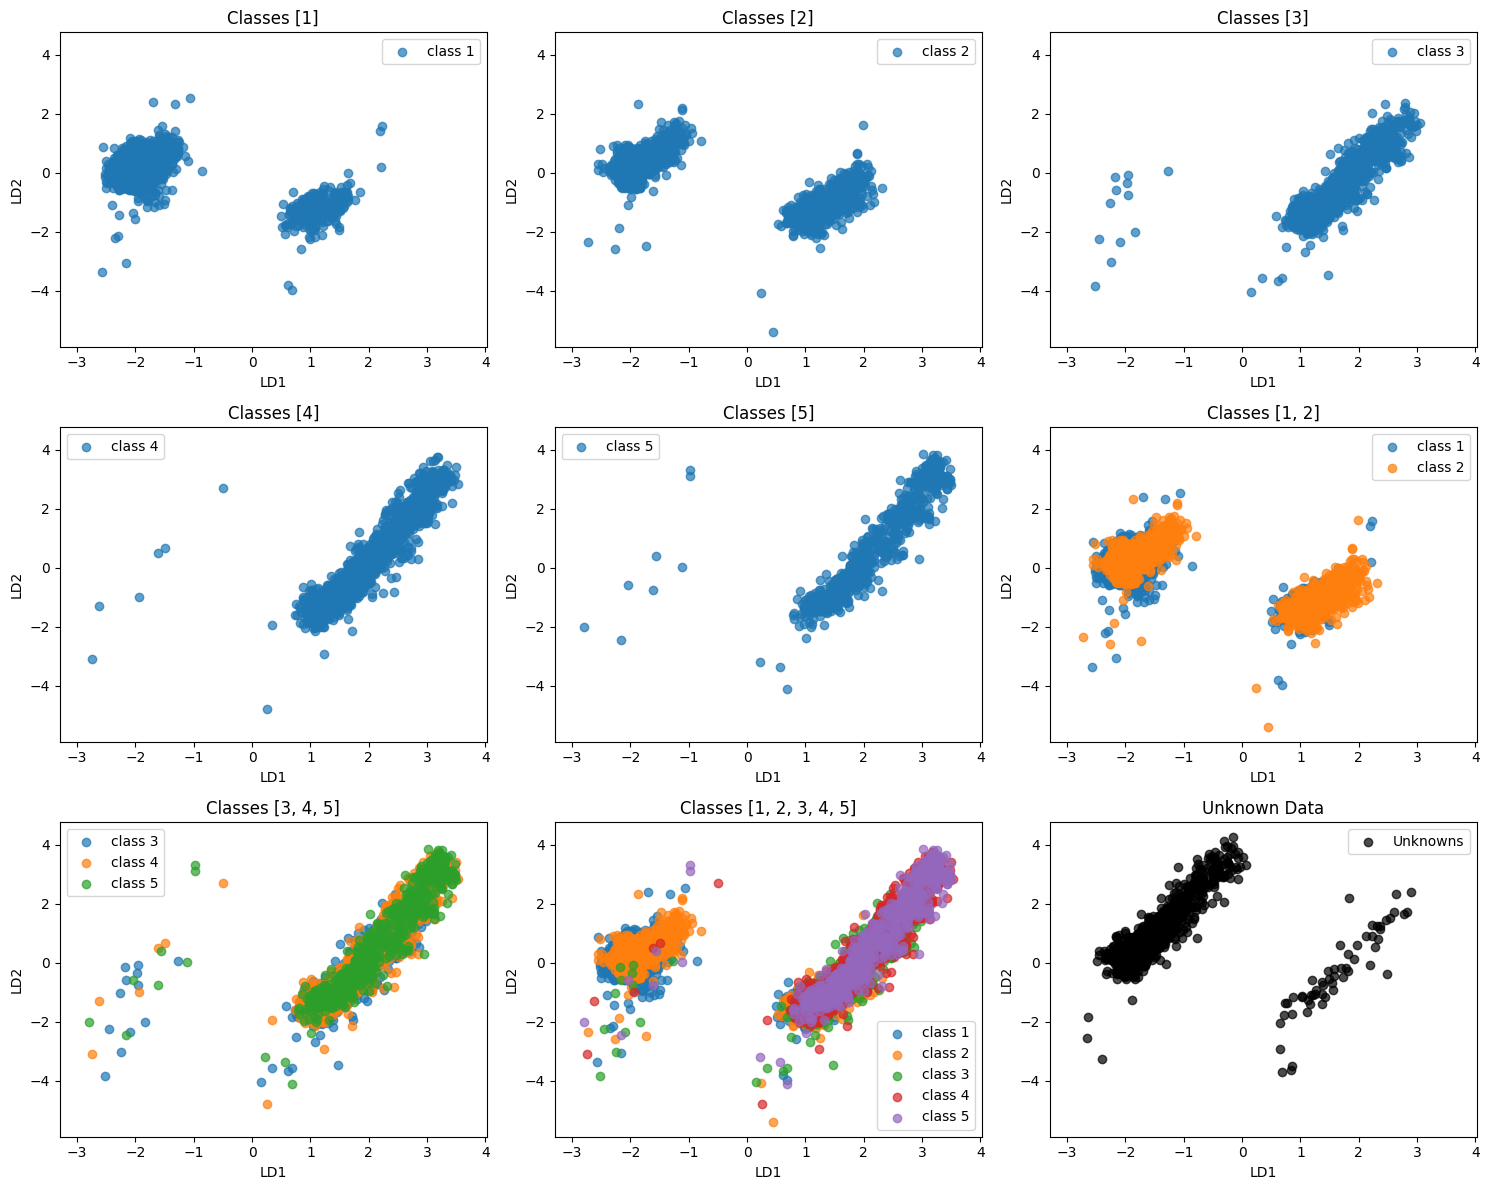

In [108]:
import matplotlib.pyplot as plt
import numpy as np

groups = [
    [1],
    [2],
    [3],
    [4],
    [5],
    [1,2],
    [3,4,5],
    [1,2,3,4,5]
]

# 전체 데이터 범위 계산
all_x = np.concatenate([features_known_df_lda[:,0], features_unknown_df_lda[:,0]])
all_y = np.concatenate([features_known_df_lda[:,1], features_unknown_df_lda[:,1]])

margin = 0.5
xlim = (all_x.min()-margin, all_x.max()+margin)
ylim = (all_y.min()-margin, all_y.max()+margin)

fig, axes = plt.subplots(3,3, figsize=(15,12))
axes = axes.flatten()

# 클래스 데이터 subplot
for ax, group in zip(axes[:8], groups):

    for c in group:
        ax.scatter(
            features_known_df_lda[income_known_df==c,0],
            features_known_df_lda[income_known_df==c,1],
            label=f"class {c}",
            alpha=0.7
        )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(f"Classes {group}")
    ax.set_xlabel("LD1")
    ax.set_ylabel("LD2")
    ax.legend()

# Unknown subplot
ax = axes[8]
ax.scatter(
    features_unknown_df_lda[:,0],
    features_unknown_df_lda[:,1],
    label="Unknowns",
    color="black",
    alpha=0.7
)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_title("Unknown Data")
ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.legend()

plt.tight_layout()
plt.show()

In [109]:
from sklearn.model_selection import train_test_split

# y_data = income_known_df
y_data = np.where(income_known_df <= 2, 0, 1)

train_X, test_X, train_y, test_y = train_test_split(
    features_known_df_scaled,
    y_data,
    stratify=y_data,
    random_state=42,
    test_size=0.2
)

In [110]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.multiclass import type_of_target


def evaluate_predictions(y_true, y_pred, y_proba, classes=None, average="macro", dataset_name="Dataset"):
    target_type = type_of_target(y_true)

    result = {
        "dataset": dataset_name,
        "target_type": target_type,
        "accuracy": accuracy_score(y_true, y_pred),
    }

    # y_proba shape 보정
    y_proba = np.asarray(y_proba)

    if target_type == "binary":
        result["recall"] = recall_score(y_true, y_pred)
        result["f1"] = f1_score(y_true, y_pred)

        # (n_samples, 2) 이면 positive class 확률만 사용
        if y_proba.ndim == 2 and y_proba.shape[1] == 2:
            y_score = y_proba[:, 1]
        # 이미 (n_samples,) 형태면 그대로 사용
        elif y_proba.ndim == 1:
            y_score = y_proba
        else:
            print(f"Binary Classification Shape Error: y_proba.shape = {y_proba.shape}")
            return {}

        result["roc_auc"] = roc_auc_score(y_true, y_score)
        result["pr_auc"] = average_precision_score(y_true, y_score)

    elif target_type == "multiclass":
        result["recall"] = recall_score(y_true, y_pred, average=average)
        result["f1"] = f1_score(y_true, y_pred, average=average)

        if y_proba.ndim != 2:
            raise ValueError(f"Multiclass classification에서는 y_proba가 2차원이어야 합니다: {y_proba.shape}")

        result["roc_auc"] = roc_auc_score(
            y_true,
            y_proba,
            multi_class="ovr",
            average=average
        )

        if classes is None:
            classes = np.unique(y_true)

        y_true_bin = label_binarize(y_true, classes=classes)
        result["pr_auc"] = average_precision_score(
            y_true_bin,
            y_proba,
            average=average
        )

    else:
        raise ValueError(f"지원하지 않는 target type입니다: {target_type}")

    return result

def print_report(res):
    print(f"========== {res["dataset"]} ==========")
    print(f"target type: {res["target_type"]}")
    for k in [key for key in res if key not in ["dataset", "target_type"]]:
        print(f"{k:>11}: {res[k]:.6f}")

In [111]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(train_X, train_y)

train_pred = lr.predict(train_X)
test_pred = lr.predict(test_X)

train_proba = lr.predict_proba(train_X)
test_proba = lr.predict_proba(test_X)

train_result = evaluate_predictions(
    y_true=train_y,
    y_pred=train_pred,
    y_proba=train_proba,
    classes=lr.classes_,
    dataset_name="Train"
)

test_result = evaluate_predictions(
    y_true=test_y,
    y_pred=test_pred,
    y_proba=test_proba,
    classes=lr.classes_,
    dataset_name="Test"
)

print_report(train_result)
print_report(test_result)

========== Train ==========
target type: binary
   accuracy: 0.886448
     recall: 0.959960
         f1: 0.873412
    roc_auc: 0.953112
     pr_auc: 0.929393
========== Test ==========
target type: binary
   accuracy: 0.887974
     recall: 0.970390
         f1: 0.876063
    roc_auc: 0.947612
     pr_auc: 0.924570


In [112]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42, max_depth=3)
rf_clf.fit(train_X, train_y)

train_pred = rf_clf.predict(train_X)
test_pred = rf_clf.predict(test_X)

train_prob = rf_clf.predict_proba(train_X)
test_prob = rf_clf.predict_proba(test_X)

train_result = evaluate_predictions(
    y_true=train_y,
    y_pred=train_pred,
    y_proba=train_proba,
    classes=rf_clf.classes_,
    dataset_name="Train"
)

test_result = evaluate_predictions(
    y_true=test_y,
    y_pred=test_pred,
    y_proba=test_proba,
    classes=rf_clf.classes_,
    dataset_name="Test"
)

print_report(train_result)
print_report(test_result)

========== Train ==========
target type: binary
   accuracy: 0.849787
     recall: 0.756729
         f1: 0.804363
    roc_auc: 0.953112
     pr_auc: 0.929393
========== Test ==========
target type: binary
   accuracy: 0.837452
     recall: 0.738896
         f1: 0.787661
    roc_auc: 0.947612
     pr_auc: 0.924570


In [113]:
def print_valcnt(arr):
    values, counts = np.unique(arr, return_counts=True)

    print("values :", " ".join(f"{v:>5}" for v in values))
    print("counts :", " ".join(f"{c:>5}" for c in counts))

In [114]:
lr_predicted = lr.predict(features_unknown_df_scaled)
rf_clf_predicted = rf_clf.predict(features_unknown_df_scaled)

print("===== 각 모델 예측된 클래스 수 =====")
print("LinearRegressor")
print_valcnt(lr_predicted)
print()
print("RandomForestClassifier")
print_valcnt(rf_clf_predicted)

print()

print("===== 서로 다르게 예측된 데이터들 ======")
print(f"다르게 예측된 데이터 수: {(lr_predicted != rf_clf_predicted).sum()}/{len(lr_predicted)}")
print(lr_predicted[(lr_predicted != rf_clf_predicted)])
print(rf_clf_predicted[(lr_predicted != rf_clf_predicted)])

===== 각 모델 예측된 클래스 수 =====
LinearRegressor
values :     0     1
counts :  1076    47

RandomForestClassifier
values :     0     1
counts :  1083    40

===== 서로 다르게 예측된 데이터들 ======
다르게 예측된 데이터 수: 17/1123
[0 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1]
[1 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0]
